# SmartHandover — Day 4: RoBERTa Text-Only Fine-Tune

Fine-tune `roberta-base` com attention pooling no MELD para 5 classes-alvo.

**Arquitetura:** TextEncoder(roberta-base) -> [768] -> Linear(768,256) -> ReLU -> Dropout(0.3) -> Linear(256,5)

**Treino:**
- WeightedRandomSampler + CrossEntropyLoss com pesos por classe
- Encoder FROZEN nos primeiros 2 epochs, depois unfreeze top 4 layers
- AdamW (lr=2e-5), linear warmup (10%), FP16 autocast
- Early stopping (patience=8) no weighted_f1

In [1]:
#%pip install torch transformers datasets pandas scikit-learn tqdm matplotlib --quiet

In [2]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [3]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


## 1. Treinar modelo

Isto demora ~15-30 min numa RTX 5060 Ti. O modelo fica guardado em `checkpoints/roberta_text_only.pt`.

In [4]:
from src.training.train_text import train_model

model, history = train_model(
    batch_size=16,
    max_epochs=40,
    lr=2e-5,
    patience=8,
    freeze_epochs=2,
    unfreeze_top_n=4,
    device=device,
)

Device: cuda
Loading MELD splits...
  Train: 8783, Val: 958


Building TextOnlyClassifier...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training for up to 40 epochs (patience=8)...
  Encoder FROZEN for first 2 epochs, then unfreeze top 4 layers.



...

  Epoch 19 | loss=0.0836 | val_loss=3.5928 | W-F1=0.5885 | M-F1=0.4666 | 22s | UNFROZEN


  Epoch 20 | loss=0.0753 | val_loss=3.8975 | W-F1=0.5968 | M-F1=0.4676 | 22s | UNFROZEN


  Epoch 21 | loss=0.0775 | val_loss=3.7802 | W-F1=0.5798 | M-F1=0.4591 | 22s | UNFROZEN


  Epoch 22 | loss=0.0642 | val_loss=4.0632 | W-F1=0.5882 | M-F1=0.4575 | 22s | UNFROZEN


  Epoch 23 | loss=0.0605 | val_loss=4.0873 | W-F1=0.6116 | M-F1=0.4738 | 22s | UNFROZEN
  Early stopping at epoch 23 (no improvement for 8 epochs).

Training complete. Best val W-F1: 0.6210


In [5]:
# Guardar historico de treino
hist_df = pd.DataFrame(history)
os.makedirs("../data/processed", exist_ok=True)
hist_df.to_csv("../data/processed/roberta_training_history.csv", index=False)
hist_df.tail()

,epoch,train_loss,val_loss,val_wf1,val_mf1
18,19,0.083573,3.592842,0.588451,0.466610
19,20,0.075321,3.897526,0.596759,0.467594
20,21,0.077493,3.780230,0.579770,0.459108
21,22,0.064154,4.063180,0.588245,0.457469
22,23,0.060530,4.087260,0.611552,0.473845


## 2. Curvas de treino

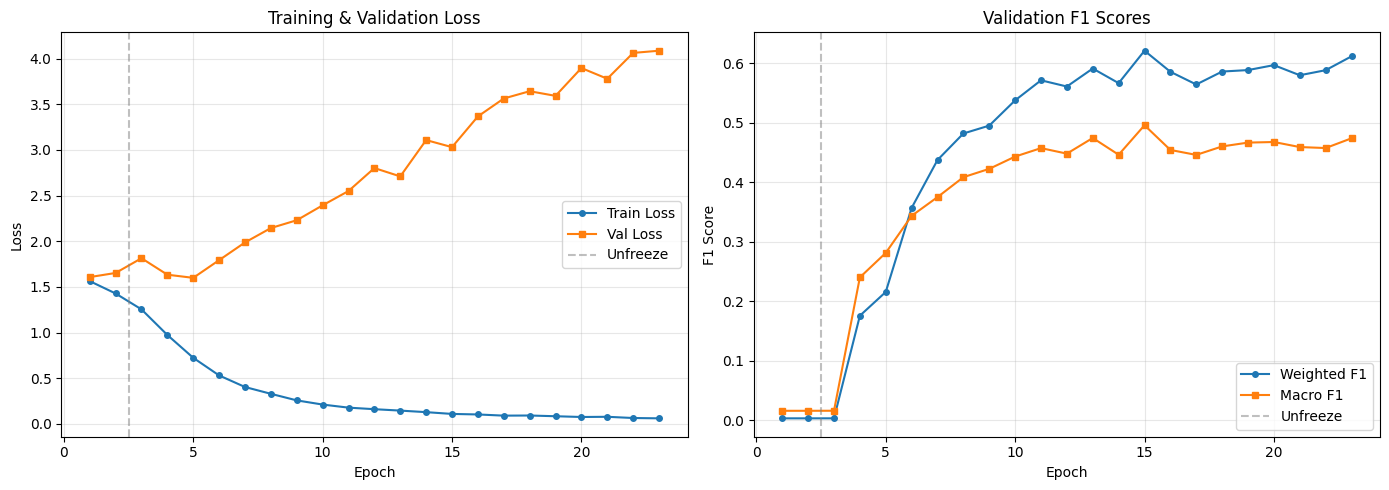

Guardado em data/processed/roberta_training_curves.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train Loss", marker="o", markersize=4)
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="Val Loss", marker="s", markersize=4)
axes[0].axvline(x=2.5, color="gray", linestyle="--", alpha=0.5, label="Unfreeze")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1
axes[1].plot(hist_df["epoch"], hist_df["val_wf1"], label="Weighted F1", marker="o", markersize=4)
axes[1].plot(hist_df["epoch"], hist_df["val_mf1"], label="Macro F1", marker="s", markersize=4)
axes[1].axvline(x=2.5, color="gray", linestyle="--", alpha=0.5, label="Unfreeze")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Validation F1 Scores")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/roberta_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado em data/processed/roberta_training_curves.png")

## 3. Carregar melhor modelo e avaliar

In [7]:
from src.training.train_text import TextOnlyClassifier, evaluate_on_test

# Carregar checkpoint
ckpt_path = "../checkpoints/roberta_text_only.pt"
best_model = TextOnlyClassifier()
best_model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
print(f"Modelo carregado de {ckpt_path}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo carregado de ../checkpoints/roberta_text_only.pt


In [8]:
# Avaliar no validation set (para grid search do ensemble)
print("A avaliar no validation set...")
val_df = evaluate_on_test(best_model, device=device, split="validation")
val_df.to_csv("../data/processed/roberta_val_predictions.csv", index=False)
print(f"Val predictions guardadas ({len(val_df)} amostras)")

# Avaliar no test set
print("\nA avaliar no test set...")
test_df = evaluate_on_test(best_model, device=device, split="test")
test_df.to_csv("../data/processed/roberta_predictions.csv", index=False)
print(f"Test predictions guardadas ({len(test_df)} amostras)")

A avaliar no validation set...


Evaluating test set: 100%|██████████| 30/30 [00:01<00:00, 29.32it/s]


Val predictions guardadas (958 amostras)

A avaliar no test set...


Evaluating test set: 100%|██████████| 73/73 [00:02<00:00, 30.70it/s]

Test predictions guardadas (2329 amostras)


## 4. Metricas no Test Set

In [9]:
from src.evaluation.metrics import compute_metrics, print_metrics
from src.data.load_meld import TARGET_LABELS, TARGET_LABEL2ID

y_true = [TARGET_LABEL2ID[l] for l in test_df["true_label"]]
y_pred = [TARGET_LABEL2ID[l] for l in test_df["predicted_class"]]

metrics = compute_metrics(y_true, y_pred, target_names=TARGET_LABELS)
print_metrics(metrics)


  Accuracy     : 0.6410
  Weighted F1  : 0.6412
  Macro F1     : 0.4677
  Frustration R: 0.1600  << KEY METRIC

  Class             Prec    Rec     F1  Support
  -------------------------------------------
  anger            0.539  0.506  0.522      413
  frustration      0.108  0.160  0.129       50 <<
  sadness          0.339  0.293  0.314      208
  neutral          0.765  0.767  0.766     1256
  satisfaction     0.589  0.627  0.607      402

  Confusion Matrix (rows=true, cols=pred):
            anger  frust  sadne  neutr  satis
    anger     209     11     26    114     53
    frust       8      8      8     20      6
    sadne      31     12     61     79     25
    neutr      94     36     71    963     92
    satis      46      7     14     83    252


## 5. Comparacao com baselines (Days 1-3)

In [10]:
rows = [("RoBERTa (fine-tuned)", metrics["weighted_f1"], metrics["macro_f1"], metrics["frustration_recall"])]

for name, path in [("VADER", "../data/processed/vader_predictions.csv"),
                    ("GoEmotions", "../data/processed/goemo_predictions.csv"),
                    ("SpeechBrain", "../data/processed/speechbrain_predictions.csv")]:
    if os.path.exists(path):
        prev = pd.read_csv(path)
        yt = [TARGET_LABEL2ID[l] for l in prev["true_label"]]
        yp = [TARGET_LABEL2ID[l] for l in prev["predicted_class"]]
        m = compute_metrics(yt, yp, target_names=TARGET_LABELS)
        rows.append((name, m["weighted_f1"], m["macro_f1"], m["frustration_recall"]))

comparison = pd.DataFrame(rows, columns=["Model", "W-F1", "M-F1", "Frust Recall"])
comparison = comparison.sort_values("W-F1", ascending=False).reset_index(drop=True)
comparison.style.format({"W-F1": "{:.4f}", "M-F1": "{:.4f}", "Frust Recall": "{:.4f}"})

,Model,W-F1,M-F1,Frust Recall
0,RoBERTa (fine-tuned),0.6412,0.4677,0.1600
1,GoEmotions,0.5596,0.4049,0.4274
2,VADER,0.4795,0.2962,0.0000
3,SpeechBrain,0.3994,0.2581,0.0000


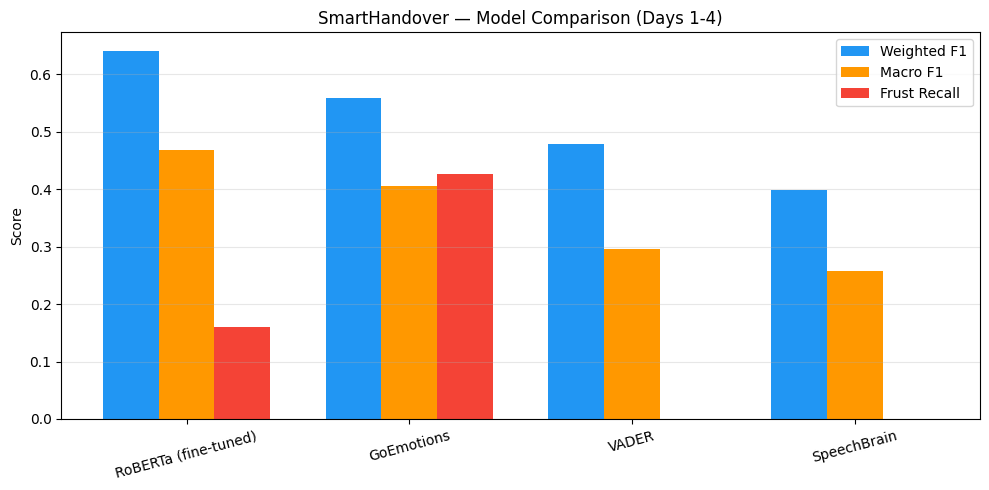

In [11]:
# Grafico de barras
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(comparison))
width = 0.25

ax.bar([i - width for i in x], comparison["W-F1"], width, label="Weighted F1", color="#2196F3")
ax.bar(x, comparison["M-F1"], width, label="Macro F1", color="#FF9800")
ax.bar([i + width for i in x], comparison["Frust Recall"], width, label="Frust Recall", color="#F44336")

ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"], rotation=15)
ax.set_ylabel("Score")
ax.set_title("SmartHandover — Model Comparison (Days 1-4)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()